In [9]:
!pip install finance-datareader --quiet
!pip install pykalman --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 248.5/248.5 kB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 141.5/141.5 kB 9.4 MB/s eta 0:00:00


In [20]:
import FinanceDataReader as fdr
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from numpy.linalg import inv
from pykalman import KalmanFilter

In [ ]:
# df_lgensol = fdr.DataReader('373220', '2020-01-01', '2025-03-15')
# df_lgensol.head(5)

In [17]:
ticker = yf.Ticker("AAPL")
data = ticker.history(period="1y")
x = data['Close']

In [25]:
kf = KalmanFilter(transition_matrices = [1],
                  observation_matrices = [1],
                  initial_state_mean = 0,
                  initial_state_covariance = 1,
                  observation_covariance=1,
                  transition_covariance=.01)

state_means, _ = kf.filter(x.values)
state_means = pd.Series(state_means.flatten(), index=x.index)

Text(0, 0.5, 'Price')

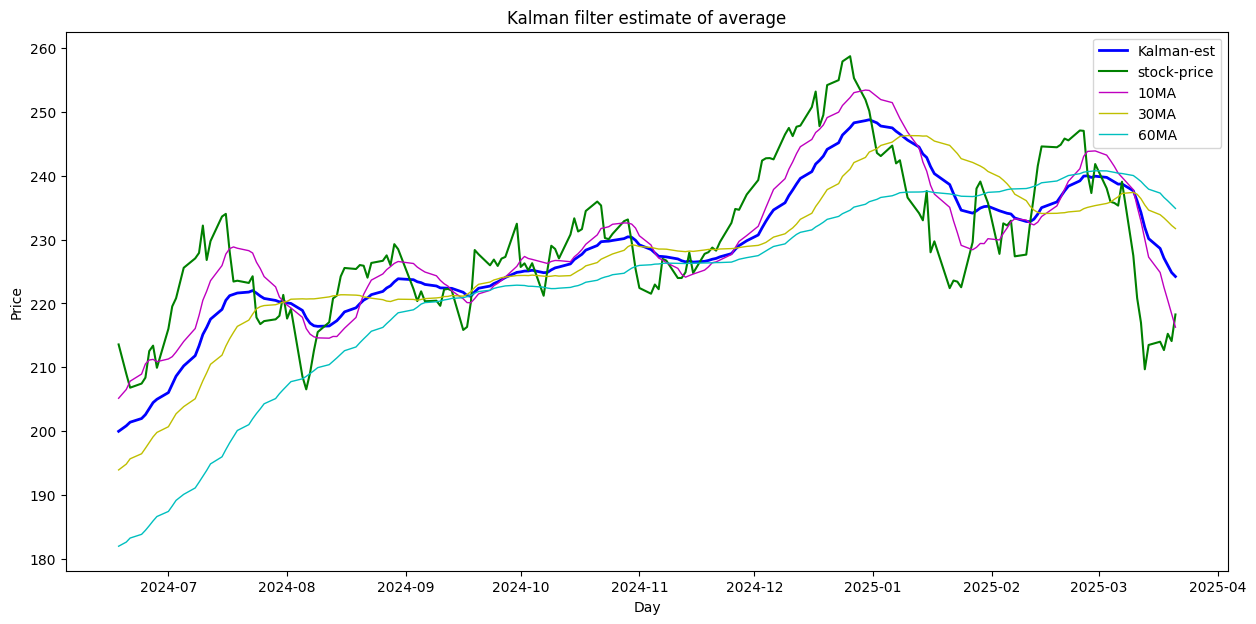

In [27]:
# 칼만필터를 이용해 예측한 주가 흐름이 실제주가, 이평선 중 어디에 더 가까운지 확인
mean10 = x.rolling(window = 10).mean()
mean30 = x.rolling(window = 30).mean()
mean60 = x.rolling(window = 60).mean()

plt.figure(figsize=(15,7))
plt.plot(state_means[60:], '-b', lw=2, )
plt.plot(x[60:],'-g',lw=1.5)
plt.plot(mean10[60:], 'm', lw=1)
plt.plot(mean30[60:], 'y', lw=1)
plt.plot(mean60[60:], 'c', lw=1)
plt.title('Kalman filter estimate of average')
plt.legend(['Kalman-est', 'stock-price', '10MA', '30MA','60MA'])
plt.xlabel('Day')
plt.ylabel('Price')